# Phase 3: Model Training
In this notebook, we will train a Random Forest and an XGBoost model on the Crop Recommendation dataset. We will evaluate both and potentially build an ensemble if needed.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display

## 1. Load Data

In [2]:
df = pd.read_csv('../data/processed/Crop_recommendation_processed.csv')
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 2. Prepare Training and Testing Sets

In [3]:
X = df.drop('label', axis=1)
y = df['label']

# XGBoost requires target labels to be encoded as integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Save the label encoder classes so we can decode predictions later
np.save('../models/label_classes.npy', label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print(f'Training shape: {X_train.shape}')
print(f'Testing shape: {X_test.shape}')

Training shape: (1760, 7)
Testing shape: (440, 7)


## 3. Train Random Forest

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f'Random Forest Accuracy: {rf_acc * 100:.2f}%')

Random Forest Accuracy: 99.32%


## 4. Train XGBoost

In [5]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f'XGBoost Accuracy: {xgb_acc * 100:.2f}%')

c:\Users\nagal\AI based crop prediction\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [13:40:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 98.41%


## 5. Evaluation and Comparison

In [6]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds, target_names=label_encoder.classes_))

print("\n========================================\n")

print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_preds, target_names=label_encoder.classes_))

Random Forest Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00 

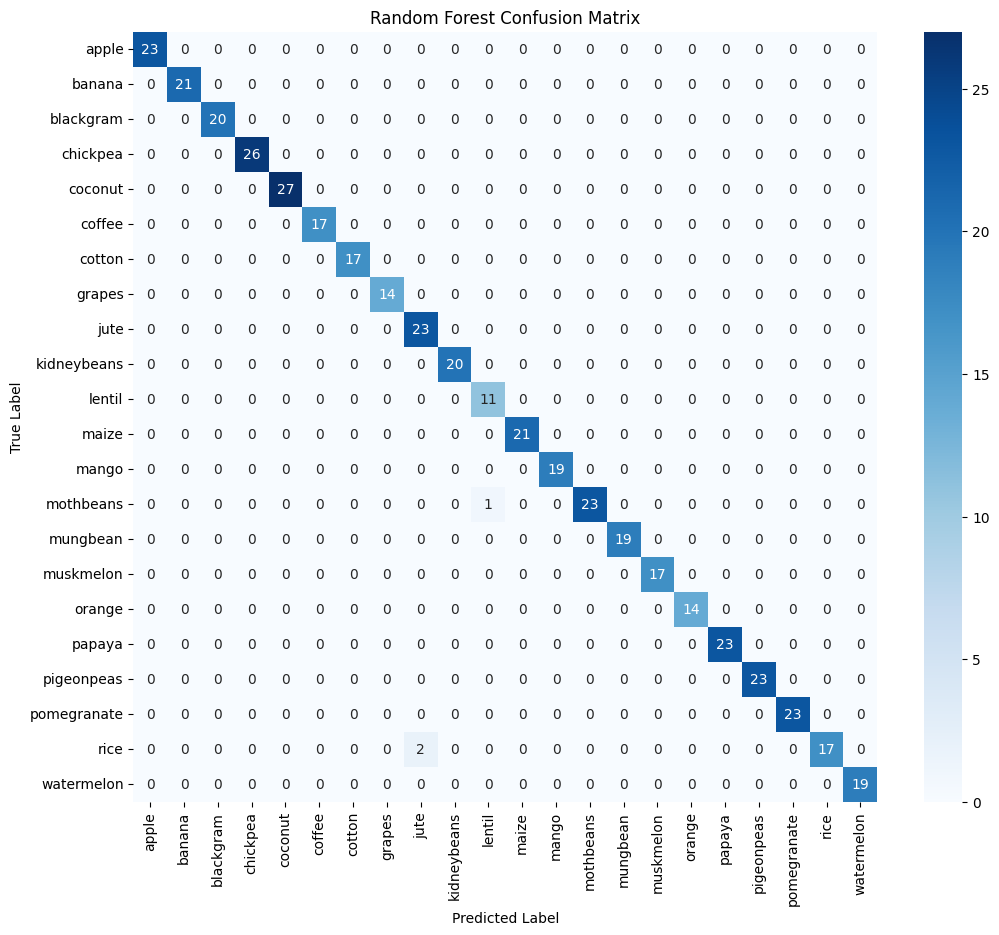

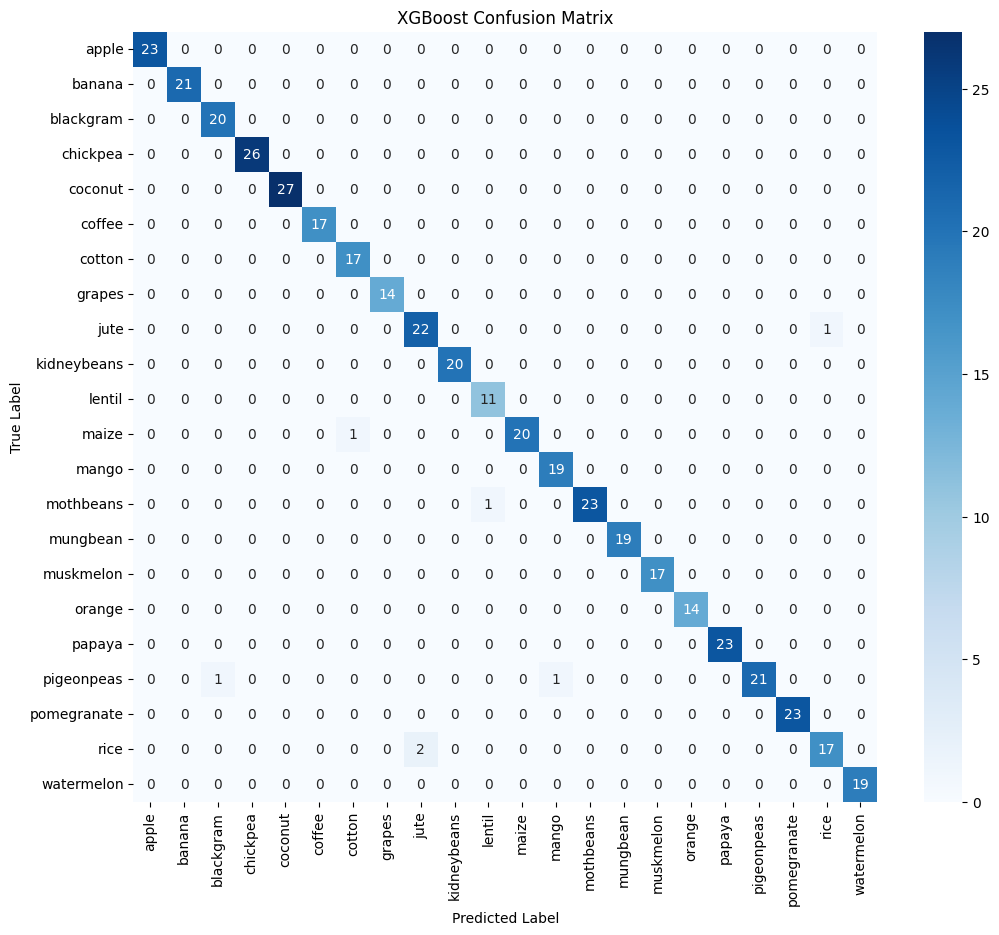

In [7]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_confusion_matrix(y_test, rf_preds, 'Random Forest Confusion Matrix')
plot_confusion_matrix(y_test, xgb_preds, 'XGBoost Confusion Matrix')

## 6. Save Best Model
Both models typically achieve >99% accuracy on this dataset. We will save the Random Forest model for simplicity, or an ensemble voting classifier if we want the best of both worlds. Here we save the Random Forest model.

In [8]:
os.makedirs('../models', exist_ok=True)
joblib.dump(rf_model, '../models/random_forest_model.joblib')
joblib.dump(xgb_model, '../models/xgboost_model.joblib')
joblib.dump(label_encoder, '../models/label_encoder.joblib')
print('Models and Label Encoder saved successfully to /models directory!')

Models and Label Encoder saved successfully to /models directory!
